# PEM charge and discharge rate calibration

This notebook contains only the calculations used for the final hydrogen charge/discharge constants in the EMS/SoH model.

The final constants are based on the **PEM polarization characteristics test**:

- charge/electrolysis calibration: Scenario 3, active charging current above 0.05 A
- discharge/fuel-cell calibration: negative PEM current, from first active discharge point to the minimum current point

The short charge tests are included only as validation of the final current-based SoH model.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

# Constants used in the calibration
MEASURED_FULL_HYDROGEN_CAPACITY_ML = 15.6
MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML = 7.6
MEASURED_USABLE_HYDROGEN_DISCHARGE_ML = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML
    - MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML
)

FARADAY_CONSTANT_C_PER_MOL = 96485
ELECTRONS_PER_H2 = 2

# Same assumption as in the original notebook.
# If another reference condition is used, change this value and report it.
MOLAR_VOLUME_H2_ML_PER_MOL = 24000

FARADAY_THEORETICAL_H2_ML_PER_C = (
    MOLAR_VOLUME_H2_ML_PER_MOL
    / (ELECTRONS_PER_H2 * FARADAY_CONSTANT_C_PER_MOL)
)

# Sensor correction from the measurement setup.
PEM_VOLTAGE_OFFSET_V = 0.064
PEM_CURRENT_SCALE = 0.843
PEM_CURRENT_OFFSET_A = 0.001

CHARGE_CURRENT_THRESHOLD_A = 0.05
DISCHARGE_CURRENT_THRESHOLD_A = -0.005

In [3]:
def find_file(filename: str) -> Path:
    """
    Find a data file either in the current folder, /mnt/data, or common project data folders.
    This makes the notebook work both in the uploaded ChatGPT environment and in the project repo.
    """
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / filename,
        cwd / "data" / "PEM_test" / "current_sweep" / filename,
        cwd / "data" / "PEM_test" / filename,
        cwd / "data" / filename,
        Path("/mnt/data") / filename,
    ]

    for parent in [cwd, *cwd.parents]:
        candidates.extend([
            parent / filename,
            parent / "data" / "PEM_test" / "current_sweep" / filename,
            parent / "data" / "PEM_test" / filename,
            parent / "data" / filename,
        ])

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find {filename}. Place it next to this notebook or in data/PEM_test/current_sweep/."
    )


def preprocess_pem_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert timestamps, create a relative time axis, and apply PEM voltage/current corrections.
    """
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["time_s"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

    df["pem_voltage_V"] = df["ina4_bus_V"] - PEM_VOLTAGE_OFFSET_V
    df["pem_current_A"] = PEM_CURRENT_SCALE * (df["ina4_current_mA"] / 1000) + PEM_CURRENT_OFFSET_A

    # Positive power during charge and positive power during discharge are handled separately later.
    df["pem_charge_power_W"] = df["pem_voltage_V"] * df["pem_current_A"]

    return df


def trapezoid_integral(y, x) -> float:
    """
    Small wrapper to keep integration calls readable.
    """
    return float(np.trapezoid(y, x))

## 1. Load the polarization test

The final charge and discharge constants are based on `PEM_polarization_characteristics.csv`.

In [4]:
polarization_file = find_file("PEM_polarization_characteristics.csv")
polarization = pd.read_csv(polarization_file)
polarization = preprocess_pem_data(polarization)

print(f"Loaded: {polarization_file}")
print(f"Rows:   {len(polarization)}")
print(f"Time:   {polarization['timestamp'].min()} to {polarization['timestamp'].max()}")

display(
    polarization[
        ["timestamp", "scenario", "mode", "time_s", "pem_voltage_V", "pem_current_A", "pem_charge_power_W"]
    ].head()
)

Loaded: C:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\PEM_test\current_sweep\PEM_polarization_characteristics.csv
Rows:   2892
Time:   2026-05-05 09:40:27 to 2026-05-05 10:31:14


,timestamp,scenario,mode,time_s,pem_voltage_V,pem_current_A,pem_charge_power_W
0,2026-05-05 09:40:27,1,Scenario 1: Grid -> Load,0.0,1.2085,0.000958,0.001158
1,2026-05-05 09:40:28,1,Scenario 1: Grid -> Load,1.0,1.2085,0.000958,0.001158
2,2026-05-05 09:40:29,1,Scenario 1: Grid -> Load,2.0,1.2085,0.000958,0.001158
3,2026-05-05 09:40:30,1,Scenario 1: Grid -> Load,3.0,1.2073,0.000958,0.001156
4,2026-05-05 09:40:31,1,Scenario 1: Grid -> Load,4.0,1.2073,0.000958,0.001156


## 2. Charge calibration from the polarization test

The active electrolysis region is selected as Scenario 3 with corrected PEM current above 0.05 A.  
The current threshold removes low-current noise and ensures that only active hydrogen production is included.

In [ ]:
# Select active charge/electrolysis region

polarization_charge = polarization[
    (polarization["scenario"] == 3)
    & (polarization["pem_current_A"] > CHARGE_CURRENT_THRESHOLD_A)
].copy()

polarization_charge["charge_time_s"] = (
    polarization_charge["time_s"] - polarization_charge["time_s"].iloc[0]
)


# Integrate current and power
full_charge_duration_s = float(polarization_charge["charge_time_s"].iloc[-1])

full_input_charge_C = trapezoid_integral(
    polarization_charge["pem_current_A"],
    polarization_charge["charge_time_s"],
)

full_input_energy_J = trapezoid_integral(
    polarization_charge["pem_charge_power_W"],
    polarization_charge["charge_time_s"],
)


# Empirical hydrogen production constants
HYDROGEN_PRODUCTION_ML_PER_INPUT_C = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_input_charge_C
)

HYDROGEN_PRODUCTION_ML_PER_INPUT_J = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_input_energy_J
)

HYDROGEN_CHARGE_RATE_ML_PER_S = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_charge_duration_s
)

HYDROGEN_CHARGE_RATE_ML_PER_MIN = (
    HYDROGEN_CHARGE_RATE_ML_PER_S * 60
)

HYDROGEN_COULOMB_EFFICIENCY = (
    HYDROGEN_PRODUCTION_ML_PER_INPUT_C / FARADAY_THEORETICAL_H2_ML_PER_C
)

charge_results = pd.DataFrame({
    "quantity": [
        "active charge duration",
        "integrated input charge",
        "integrated input energy",
        "measured full H2 capacity",
        "H2 production constant",
        "H2 energy constant",
        "average H2 charge rate",
        "average H2 charge rate",
        "Faradaic efficiency estimate",
    ],
    "value": [
        full_charge_duration_s,
        full_input_charge_C,
        full_input_energy_J,
        MEASURED_FULL_HYDROGEN_CAPACITY_ML,
        HYDROGEN_PRODUCTION_ML_PER_INPUT_C,
        HYDROGEN_PRODUCTION_ML_PER_INPUT_J,
        HYDROGEN_CHARGE_RATE_ML_PER_S,
        HYDROGEN_CHARGE_RATE_ML_PER_MIN,
        100 * HYDROGEN_COULOMB_EFFICIENCY,
    ],
    "unit": [
        "s", "C", "J", "mL", "mL/C", "mL/J", "mL/s", "mL/min", "%"
    ],
})

display(charge_results)

print(f"Final EMS charge constant: {HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.5f} mL/C")

,quantity,value,unit
0,active charge duration,869.000000,s
1,integrated input charge,149.695466,C
2,integrated input energy,219.415498,J
3,measured full H2 capacity,15.600000,mL
4,H2 production constant,0.104212,mL/C
5,H2 energy constant,0.071098,mL/J
6,average H2 charge rate,0.017952,mL/s
7,average H2 charge rate,1.077100,mL/min
8,Faradaic efficiency estimate,83.790447,%


Final EMS charge constant: 0.10421 mL/C


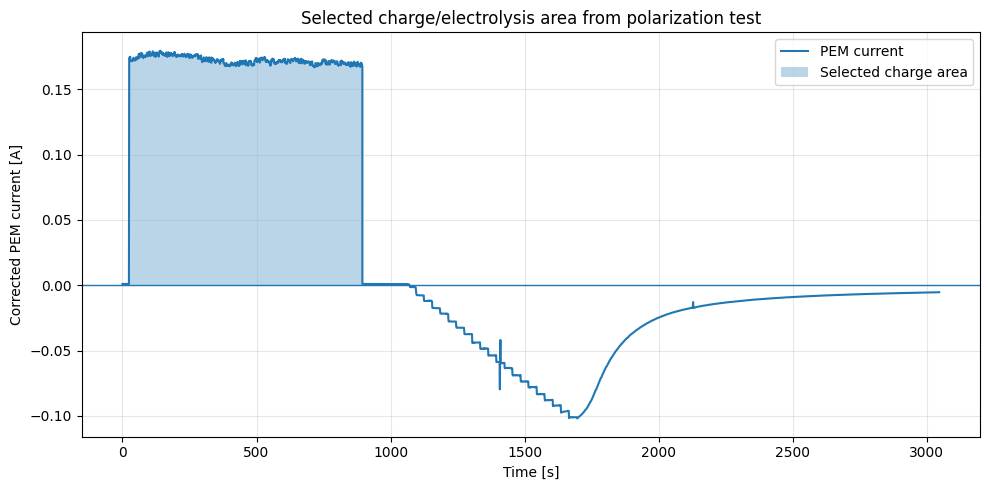

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    polarization["time_s"],
    polarization["pem_current_A"],
    label="PEM current",
    linewidth=1.5,
)

ax.fill_between(
    polarization_charge["time_s"],
    polarization_charge["pem_current_A"],
    alpha=0.3,
    label="Selected charge area",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Corrected PEM current [A]")
ax.set_title("Selected charge/electrolysis area from polarization test")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

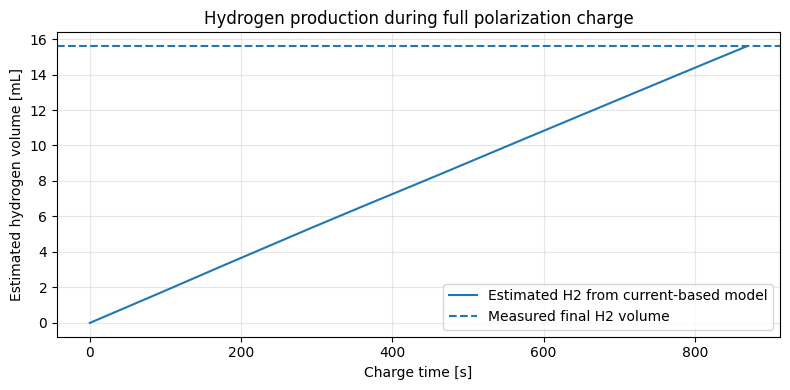

In [7]:
# Cumulative hydrogen production during the selected charge region using the final current-based EMS constant.
charge_profile = polarization_charge.copy()
charge_profile["dt_s"] = charge_profile["charge_time_s"].diff().fillna(0)

charge_profile["dQ_C"] = charge_profile["pem_current_A"] * charge_profile["dt_s"]
charge_profile["cumulative_charge_C"] = charge_profile["dQ_C"].cumsum()
charge_profile["estimated_H2_mL"] = (
    charge_profile["cumulative_charge_C"] * HYDROGEN_PRODUCTION_ML_PER_INPUT_C
)

plt.figure(figsize=(8, 4))
plt.plot(
    charge_profile["charge_time_s"],
    charge_profile["estimated_H2_mL"],
    label="Estimated H2 from current-based model",
)

plt.axhline(
    MEASURED_FULL_HYDROGEN_CAPACITY_ML,
    linestyle="--",
    label="Measured final H2 volume",
)

plt.xlabel("Charge time [s]")
plt.ylabel("Estimated hydrogen volume [mL]")
plt.title("Hydrogen production during full polarization charge")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Short-test validation of the final SoH charge model

The final SoH model uses the current-based constant from the polarization test:

\[
\Delta V_{H_2} = k_{H_2,Q} \cdot I_{\mathrm{PEM}} \cdot \Delta t
\]

The short tests are therefore used as a validation of the final charge constant.  
If the original short-test CSV files and volume readings are available in the project folder, they are loaded automatically. Otherwise, the summary table from the previous notebook run is used.

In [16]:
# 1. Locate project root and load short-test files

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

readings_file = PROJECT_ROOT / "data/PEM_test/volume_readings/readings.csv"
pem_folder = PROJECT_ROOT / "data/PEM_test/charge_discharge"

volume_readings = pd.read_csv(readings_file)
test_files = sorted(pem_folder.glob("discharge_*s_r1.csv"))

if len(test_files) == 0:
    raise FileNotFoundError(f"No short-test CSV files found in: {pem_folder}")

print(f"Loaded volume readings from: {readings_file}")
print(f"Found {len(test_files)} short-test files in: {pem_folder}")



Loaded volume readings from: C:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\PEM_test\volume_readings\readings.csv
Found 9 short-test files in: C:\Users\matil\OneDrive\Skrivebord\Studieportefølje\repos\Bachelor\data\PEM_test\charge_discharge


Extracting content of short files 

In [17]:
def parse_setpoints(file_name):
    """
    Example:
    discharge_040A_120s_r1.csv -> current = 0.40 A, duration = 120 s
    """
    parts = file_name.replace(".csv", "").split("_")
    current_A = int(parts[1].replace("A", "")) / 100
    duration_s = int(parts[2].replace("s", ""))
    return current_A, duration_s


def load_active_charge_part(file):
    """
    Load one short-test file and select only the active electrolysis section.
    Same sensor calibration and filtering as used for the polarization test.
    """
    df = pd.read_csv(file)

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["time_s"] = (
        df["timestamp"] - df["timestamp"].iloc[0]
    ).dt.total_seconds()

    # Sensor calibration
    df["pem_voltage_V"] = df["ina4_bus_V"] - 0.064
    df["pem_current_A"] = 0.843 * (df["ina4_current_mA"] / 1000) + 0.001

    # Charging power in electrolysis mode
    df["pem_charge_power_W"] = (
        df["pem_voltage_V"] * df["pem_current_A"]
    )

    # Select active electrolysis region
    charge = df[
        (df["scenario"] == 3)
        & (df["pem_current_A"] > 0.05)
    ].copy()

    if charge.empty:
        raise ValueError(f"No active charge region found in {file.name}")

    charge["charge_time_s"] = (
        charge["time_s"] - charge["time_s"].iloc[0]
    )

    return charge

Calculate measured charge form each short test 

In [18]:
rows = []

for file in test_files:
    current_setpoint_A, duration_setpoint_s = parse_setpoints(file.name)

    charge = load_active_charge_part(file)

    input_charge_C = np.trapezoid(
        charge["pem_current_A"],
        charge["charge_time_s"],
    )

    input_energy_J = np.trapezoid(
        charge["pem_charge_power_W"],
        charge["charge_time_s"],
    )

    volume_match = volume_readings[
        (volume_readings["current_A"] == current_setpoint_A)
        & (volume_readings["time_s"] == duration_setpoint_s)
    ]

    if volume_match.empty:
        raise ValueError(
            f"No manual volume reading found for {file.name} "
            f"with current={current_setpoint_A} A and time={duration_setpoint_s} s"
        )

    measured_h2_mL = volume_match["volume_mL"].iloc[0]

    rows.append({
        "file": file.name,
        "current_setpoint_A": current_setpoint_A,
        "duration_setpoint_s": duration_setpoint_s,
        "input_charge_C": input_charge_C,
        "input_energy_J": input_energy_J,
        "measured_h2_mL": measured_h2_mL,
    })

short_validation = (
    pd.DataFrame(rows)
    .sort_values(["current_setpoint_A", "duration_setpoint_s"])
    .reset_index(drop=True)
)

Validate final model on short tests 

In [20]:
# Current-based SoH model:
# Delta H2 = k_charge * integral(I dt)
short_validation["predicted_h2_current_model_mL"] = (
    short_validation["input_charge_C"]
    * HYDROGEN_PRODUCTION_ML_PER_INPUT_C
)

# Energy-based comparison:
# Delta H2 = k_energy * integral(P dt)
short_validation["predicted_h2_energy_model_mL"] = (
    short_validation["input_energy_J"]
    * HYDROGEN_PRODUCTION_ML_PER_INPUT_J
)

short_validation["current_model_error_mL"] = (
    short_validation["predicted_h2_current_model_mL"]
    - short_validation["measured_h2_mL"]
)

short_validation["current_model_error_percent"] = (
    100
    * short_validation["current_model_error_mL"]
    / short_validation["measured_h2_mL"]
)

short_validation["energy_model_error_mL"] = (
    short_validation["predicted_h2_energy_model_mL"]
    - short_validation["measured_h2_mL"]
)

short_validation["energy_model_error_percent"] = (
    100
    * short_validation["energy_model_error_mL"]
    / short_validation["measured_h2_mL"]
)

display(short_validation)

#summary
mae_current = short_validation["current_model_error_mL"].abs().mean()
rmse_current = np.sqrt(
    np.mean(short_validation["current_model_error_mL"] ** 2)
)

mae_energy = short_validation["energy_model_error_mL"].abs().mean()
rmse_energy = np.sqrt(
    np.mean(short_validation["energy_model_error_mL"] ** 2)
)

print("Validation of final polarization-based model on short tests")
print("----------------------------------------------------------")
print(f"Current-based model constant: {HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.5f} mL/C")
print(f"Energy-based model constant:  {HYDROGEN_PRODUCTION_ML_PER_INPUT_J:.5f} mL/J")
print()
print(f"Current-based MAE:  {mae_current:.3f} mL")
print(f"Current-based RMSE: {rmse_current:.3f} mL")
print(f"Energy-based MAE:   {mae_energy:.3f} mL")
print(f"Energy-based RMSE:  {rmse_energy:.3f} mL")



,file,current_setpoint_A,duration_setpoint_s,input_charge_C,input_energy_J,measured_h2_mL,predicted_h2_current_model_mL,predicted_h2_energy_model_mL,current_model_error_mL,current_model_error_percent,energy_model_error_mL,energy_model_error_percent
0,discharge_020A_30s_r1.csv,0.2,30,5.999188,9.006077,0.2,0.625185,0.640314,0.425185,212.592419,0.440314,220.156970
1,discharge_020A_60s_r1.csv,0.2,60,11.999715,17.891981,1.6,1.250509,1.272084,-0.349491,-21.843179,-0.327916,-20.494763
2,discharge_020A_120s_r1.csv,0.2,120,23.635624,37.502336,3.0,2.463106,2.666341,-0.536894,-17.896481,-0.333659,-11.121980
3,discharge_030A_30s_r1.csv,0.3,30,8.699213,14.539331,1.6,0.906559,1.033717,-0.693441,-43.340084,-0.566283,-35.392676
4,discharge_030A_60s_r1.csv,0.3,60,17.983571,27.872162,2.2,1.874096,1.981655,-0.325904,-14.813808,-0.218345,-9.924793
5,discharge_030A_120s_r1.csv,0.3,120,35.736867,54.424084,4.2,3.724195,3.869443,-0.475805,-11.328687,-0.330557,-7.870410
6,discharge_040A_30s_r1.csv,0.4,30,11.979283,19.302371,2.2,1.248380,1.372360,-0.951620,-43.255459,-0.827640,-37.620012
7,discharge_040A_60s_r1.csv,0.4,60,24.000747,38.133061,4.0,2.501156,2.711184,-1.498844,-37.471110,-1.288816,-32.220405
8,discharge_040A_120s_r1.csv,0.4,120,47.939512,78.259763,6.0,4.995852,5.564112,-1.004148,-16.735800,-0.435888,-7.264808


Validation of final polarization-based model on short tests
----------------------------------------------------------
Current-based model constant: 0.10421 mL/C
Energy-based model constant:  0.07110 mL/J

Current-based MAE:  0.696 mL
Current-based RMSE: 0.786 mL
Energy-based MAE:   0.530 mL
Energy-based RMSE:  0.617 mL


Measured vs predicted volume

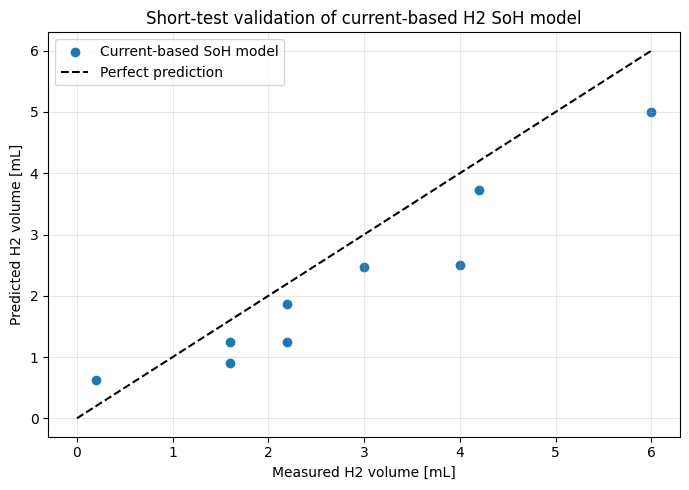

In [ ]:
# Plot measured vs predicted hydrogen volume


max_h2 = max(
    short_validation["measured_h2_mL"].max(),
    short_validation["predicted_h2_current_model_mL"].max(),
)

plt.figure(figsize=(7, 5))

plt.scatter(
    short_validation["measured_h2_mL"],
    short_validation["predicted_h2_current_model_mL"],
    label="Current-based SoH model",
)

plt.plot(
    [0, max_h2],
    [0, max_h2],
    linestyle="--",
    color="black",
    label="Perfect prediction",
)

plt.title("Short-test validation of current-based H2 SoH model")
plt.xlabel("Measured H2 volume [mL]")
plt.ylabel("Predicted H2 volume [mL]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Duration vs current level plot 

In [8]:
EMBEDDED_SHORT_TEST_SUMMARY = pd.DataFrame([
    {
        "file": "discharge_020A_30s_r1.csv",
        "current_setpoint_A": 0.2,
        "duration_setpoint_s": 30,
        "hydrogen_volume_mL": 0.2,
        "input_charge_C": 5.999283,
        "input_energy_J": 9.026946,
        "hydrogen_mL_per_C": 0.033337,
        "hydrogen_mL_per_J": 0.022156
    },
    {
        "file": "discharge_020A_60s_r1.csv",
        "current_setpoint_A": 0.2,
        "duration_setpoint_s": 60,
        "hydrogen_volume_mL": 1.6,
        "input_charge_C": 11.999809,
        "input_energy_J": 17.924721,
        "hydrogen_mL_per_C": 0.133335,
        "hydrogen_mL_per_J": 0.089262
    },
    {
        "file": "discharge_020A_120s_r1.csv",
        "current_setpoint_A": 0.2,
        "duration_setpoint_s": 120,
        "hydrogen_volume_mL": 3.0,
        "input_charge_C": 23.635698,
        "input_energy_J": 37.491836,
        "hydrogen_mL_per_C": 0.126927,
        "hydrogen_mL_per_J": 0.080017
    },
    {
        "file": "discharge_030A_30s_r1.csv",
        "current_setpoint_A": 0.3,
        "duration_setpoint_s": 30,
        "hydrogen_volume_mL": 1.6,
        "input_charge_C": 8.699508,
        "input_energy_J": 14.687808,
        "hydrogen_mL_per_C": 0.183918,
        "hydrogen_mL_per_J": 0.108934
    },
    {
        "file": "discharge_030A_60s_r1.csv",
        "current_setpoint_A": 0.3,
        "duration_setpoint_s": 60,
        "hydrogen_volume_mL": 2.2,
        "input_charge_C": 17.983824,
        "input_energy_J": 28.00629,
        "hydrogen_mL_per_C": 0.122332,
        "hydrogen_mL_per_J": 0.078554
    },
    {
        "file": "discharge_030A_120s_r1.csv",
        "current_setpoint_A": 0.3,
        "duration_setpoint_s": 120,
        "hydrogen_volume_mL": 4.2,
        "input_charge_C": 35.737394,
        "input_energy_J": 54.565123,
        "hydrogen_mL_per_C": 0.117524,
        "hydrogen_mL_per_J": 0.076972
    },
    {
        "file": "discharge_040A_30s_r1.csv",
        "current_setpoint_A": 0.4,
        "duration_setpoint_s": 30,
        "hydrogen_volume_mL": 2.2,
        "input_charge_C": 11.979546,
        "input_energy_J": 19.370871,
        "hydrogen_mL_per_C": 0.183646,
        "hydrogen_mL_per_J": 0.113573
    },
    {
        "file": "discharge_040A_60s_r1.csv",
        "current_setpoint_A": 0.4,
        "duration_setpoint_s": 60,
        "hydrogen_volume_mL": 4.0,
        "input_charge_C": 24.001305,
        "input_energy_J": 38.185626,
        "hydrogen_mL_per_C": 0.166658,
        "hydrogen_mL_per_J": 0.104751
    },
    {
        "file": "discharge_040A_120s_r1.csv",
        "current_setpoint_A": 0.4,
        "duration_setpoint_s": 120,
        "hydrogen_volume_mL": 6.0,
        "input_charge_C": 47.939786,
        "input_energy_J": 78.303592,
        "hydrogen_mL_per_C": 0.125157,
        "hydrogen_mL_per_J": 0.076625
    }
])

def parse_short_test_setpoints(file_name: str):
    # Example: discharge_040A_120s_r1.csv -> 0.40 A and 120 s.
    parts = file_name.replace(".csv", "").split("_")
    current_A = int(parts[1].replace("A", "")) / 100
    duration_s = int(parts[2].replace("s", ""))
    return current_A, duration_s


def find_optional_file(filename: str, extra_subdirs=None):
    extra_subdirs = extra_subdirs or []
    cwd = Path.cwd().resolve()

    candidates = [cwd / filename, Path("/mnt/data") / filename]
    for parent in [cwd, *cwd.parents]:
        for subdir in extra_subdirs:
            candidates.append(parent / subdir / filename)

    for path in candidates:
        if path.exists():
            return path
    return None


def find_optional_folder(folder_name: str, extra_subdirs=None):
    extra_subdirs = extra_subdirs or []
    cwd = Path.cwd().resolve()

    candidates = [cwd / folder_name]
    for parent in [cwd, *cwd.parents]:
        for subdir in extra_subdirs:
            candidates.append(parent / subdir / folder_name)

    for path in candidates:
        if path.exists() and path.is_dir():
            return path
    return None


def load_short_test_summary():
    readings_file = find_optional_file(
        "readings.csv",
        extra_subdirs=[
            Path("data") / "PEM_test" / "volume_readings",
            Path("PEM_test") / "volume_readings",
        ],
    )

    pem_folder = find_optional_folder(
        "charge_discharge",
        extra_subdirs=[
            Path("data") / "PEM_test",
            Path("PEM_test"),
        ],
    )

    if readings_file is None or pem_folder is None:
        print("Short-test raw files not found. Using embedded summary from the original notebook output.")
        return EMBEDDED_SHORT_TEST_SUMMARY.copy()

    volume_readings = pd.read_csv(readings_file)
    test_files = sorted(pem_folder.glob("discharge_*s_r1.csv"))

    rows = []
    for file in test_files:
        current_setpoint_A, duration_setpoint_s = parse_short_test_setpoints(file.name)

        df = pd.read_csv(file)
        df = preprocess_pem_data(df)

        charge = df[
            (df["scenario"] == 3)
            & (df["pem_current_A"] > CHARGE_CURRENT_THRESHOLD_A)
        ].copy()

        if charge.empty:
            continue

        charge["charge_time_s"] = charge["time_s"] - charge["time_s"].iloc[0]

        input_charge_C = trapezoid_integral(
            charge["pem_current_A"],
            charge["charge_time_s"],
        )

        input_energy_J = trapezoid_integral(
            charge["pem_charge_power_W"],
            charge["charge_time_s"],
        )

        volume_match = volume_readings[
            (volume_readings["current_A"] == current_setpoint_A)
            & (volume_readings["time_s"] == duration_setpoint_s)
        ]

        if volume_match.empty:
            continue

        hydrogen_volume_mL = float(volume_match["volume_mL"].iloc[0])

        rows.append({
            "file": file.name,
            "current_setpoint_A": current_setpoint_A,
            "duration_setpoint_s": duration_setpoint_s,
            "hydrogen_volume_mL": hydrogen_volume_mL,
            "input_charge_C": input_charge_C,
            "input_energy_J": input_energy_J,
            "hydrogen_mL_per_C": hydrogen_volume_mL / input_charge_C,
            "hydrogen_mL_per_J": hydrogen_volume_mL / input_energy_J,
        })

    print(f"Loaded {len(rows)} short tests from raw files.")
    return pd.DataFrame(rows)


short_summary = load_short_test_summary()
short_summary = short_summary.sort_values(
    ["current_setpoint_A", "duration_setpoint_s"]
).reset_index(drop=True)

display(short_summary)

Loaded 9 short tests from raw files.


,file,current_setpoint_A,duration_setpoint_s,hydrogen_volume_mL,input_charge_C,input_energy_J,hydrogen_mL_per_C,hydrogen_mL_per_J
0,discharge_020A_30s_r1.csv,0.2,30,0.2,5.999188,9.006077,0.033338,0.022207
1,discharge_020A_60s_r1.csv,0.2,60,1.6,11.999715,17.891981,0.133337,0.089426
2,discharge_020A_120s_r1.csv,0.2,120,3.0,23.635624,37.502336,0.126927,0.079995
3,discharge_030A_30s_r1.csv,0.3,30,1.6,8.699213,14.539331,0.183925,0.110046
4,discharge_030A_60s_r1.csv,0.3,60,2.2,17.983571,27.872162,0.122334,0.078932
5,discharge_030A_120s_r1.csv,0.3,120,4.2,35.736867,54.424084,0.117526,0.077172
6,discharge_040A_30s_r1.csv,0.4,30,2.2,11.979283,19.302371,0.183650,0.113976
7,discharge_040A_60s_r1.csv,0.4,60,4.0,24.000747,38.133061,0.166661,0.104896
8,discharge_040A_120s_r1.csv,0.4,120,6.0,47.939512,78.259763,0.125158,0.076668


In [9]:
short_validation = short_summary.copy()

# Validation of the final SoH charge model:
# predicted H2 = input charge from each short test * final polarization-test mL/C constant
short_validation["predicted_H2_mL"] = (
    short_validation["input_charge_C"] * HYDROGEN_PRODUCTION_ML_PER_INPUT_C
)

short_validation["error_mL"] = (
    short_validation["hydrogen_volume_mL"] - short_validation["predicted_H2_mL"]
)

short_validation["error_percent"] = (
    100 * short_validation["error_mL"] / short_validation["hydrogen_volume_mL"]
)

validation_metrics = {
    "mean_absolute_error_mL": short_validation["error_mL"].abs().mean(),
    "mean_error_mL": short_validation["error_mL"].mean(),
    "mean_absolute_percentage_error_percent": short_validation["error_percent"].abs().mean(),
}

display(
    short_validation[
        [
            "file",
            "current_setpoint_A",
            "duration_setpoint_s",
            "input_charge_C",
            "hydrogen_volume_mL",
            "predicted_H2_mL",
            "error_mL",
            "error_percent",
        ]
    ]
)

print("Validation metrics for final current-based SoH charge model:")
for key, value in validation_metrics.items():
    print(f"{key}: {value:.3f}")

,file,current_setpoint_A,duration_setpoint_s,input_charge_C,hydrogen_volume_mL,predicted_H2_mL,error_mL,error_percent
0,discharge_020A_30s_r1.csv,0.2,30,5.999188,0.2,0.625185,-0.425185,-212.592419
1,discharge_020A_60s_r1.csv,0.2,60,11.999715,1.6,1.250509,0.349491,21.843179
2,discharge_020A_120s_r1.csv,0.2,120,23.635624,3.0,2.463106,0.536894,17.896481
3,discharge_030A_30s_r1.csv,0.3,30,8.699213,1.6,0.906559,0.693441,43.340084
4,discharge_030A_60s_r1.csv,0.3,60,17.983571,2.2,1.874096,0.325904,14.813808
5,discharge_030A_120s_r1.csv,0.3,120,35.736867,4.2,3.724195,0.475805,11.328687
6,discharge_040A_30s_r1.csv,0.4,30,11.979283,2.2,1.248380,0.951620,43.255459
7,discharge_040A_60s_r1.csv,0.4,60,24.000747,4.0,2.501156,1.498844,37.471110
8,discharge_040A_120s_r1.csv,0.4,120,47.939512,6.0,4.995852,1.004148,16.735800


Validation metrics for final current-based SoH charge model:
mean_absolute_error_mL: 0.696
mean_error_mL: 0.601
mean_absolute_percentage_error_percent: 46.586


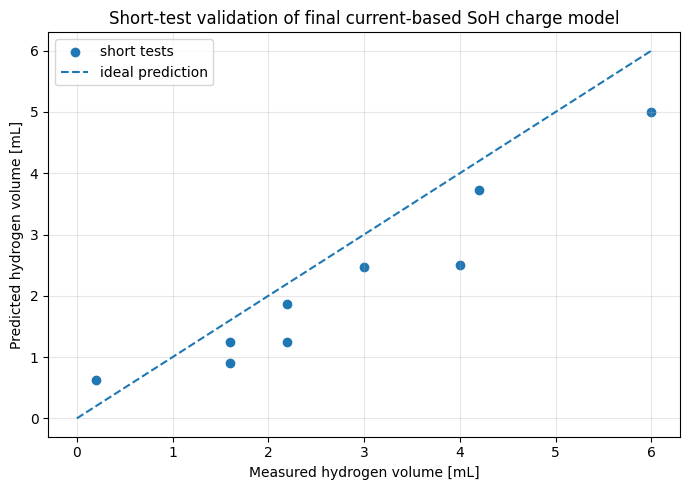

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(
    short_validation["hydrogen_volume_mL"],
    short_validation["predicted_H2_mL"],
    label="short tests",
)

max_volume = max(
    short_validation["hydrogen_volume_mL"].max(),
    short_validation["predicted_H2_mL"].max(),
)

plt.plot(
    [0, max_volume],
    [0, max_volume],
    linestyle="--",
    label="ideal prediction",
)

plt.xlabel("Measured hydrogen volume [mL]")
plt.ylabel("Predicted hydrogen volume [mL]")
plt.title("Short-test validation of final current-based SoH charge model")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Discharge calibration from the polarization test

The active fuel-cell discharge region is selected from the first negative-current point to the minimum current point.  
The current magnitude is integrated, because the measured current is negative during discharge by convention.

In [ ]:

# Select active discharge/fuel-cell region

discharge_all = polarization[
    polarization["pem_current_A"] < DISCHARGE_CURRENT_THRESHOLD_A
].copy()

idx_min_current = discharge_all["pem_current_A"].idxmin()
t_min_current = float(polarization.loc[idx_min_current, "time_s"])
t_discharge_start = float(discharge_all["time_s"].iloc[0])

active_discharge = polarization[
    (polarization["time_s"] >= t_discharge_start)
    & (polarization["time_s"] <= t_min_current)
    & (polarization["pem_current_A"] < DISCHARGE_CURRENT_THRESHOLD_A)
].copy()

active_discharge["discharge_time_s"] = (
    active_discharge["time_s"] - active_discharge["time_s"].iloc[0]
)

# Use positive current magnitude for integration.
active_discharge["pem_discharge_current_A"] = -active_discharge["pem_current_A"]
active_discharge["pem_discharge_power_W"] = (
    active_discharge["pem_voltage_V"] * active_discharge["pem_discharge_current_A"]
)

# Integrate output current and power

active_discharge_duration_s = float(active_discharge["discharge_time_s"].iloc[-1])

active_output_charge_C = trapezoid_integral(
    active_discharge["pem_discharge_current_A"],
    active_discharge["discharge_time_s"],
)

active_output_energy_J = trapezoid_integral(
    active_discharge["pem_discharge_power_W"],
    active_discharge["discharge_time_s"],
)


# Empirical discharge constants
HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / active_output_charge_C
)

HYDROGEN_DISCHARGE_ML_PER_OUTPUT_J = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / active_output_energy_J
)

HYDROGEN_DISCHARGE_RATE_ML_PER_S = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / active_discharge_duration_s
)

HYDROGEN_DISCHARGE_RATE_ML_PER_MIN = (
    HYDROGEN_DISCHARGE_RATE_ML_PER_S * 60
)

discharge_results = pd.DataFrame({
    "quantity": [
        "active discharge start",
        "minimum current time",
        "active discharge duration",
        "integrated output charge",
        "integrated output energy",
        "measured H2 used",
        "H2 discharge constant",
        "H2 discharge energy constant",
        "average H2 discharge rate",
        "average H2 discharge rate",
    ],
    "value": [
        t_discharge_start,
        t_min_current,
        active_discharge_duration_s,
        active_output_charge_C,
        active_output_energy_J,
        MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
        HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C,
        HYDROGEN_DISCHARGE_ML_PER_OUTPUT_J,
        HYDROGEN_DISCHARGE_RATE_ML_PER_S,
        HYDROGEN_DISCHARGE_RATE_ML_PER_MIN,
    ],
    "unit": [
        "s", "s", "s", "C", "J", "mL", "mL/C", "mL/J", "mL/s", "mL/min"
    ],
})

display(discharge_results)

print(f"Final EMS discharge constant: {HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C:.5f} mL/C")

,quantity,value,unit
0,active discharge start,1096.000000,s
1,minimum current time,1697.000000,s
2,active discharge duration,601.000000,s
3,integrated output charge,33.406294,C
4,integrated output energy,17.123270,J
5,measured H2 used,8.000000,mL
6,H2 discharge constant,0.239476,mL/C
7,H2 discharge energy constant,0.467200,mL/J
8,average H2 discharge rate,0.013311,mL/s
9,average H2 discharge rate,0.798669,mL/min


Final EMS discharge constant: 0.23948 mL/C


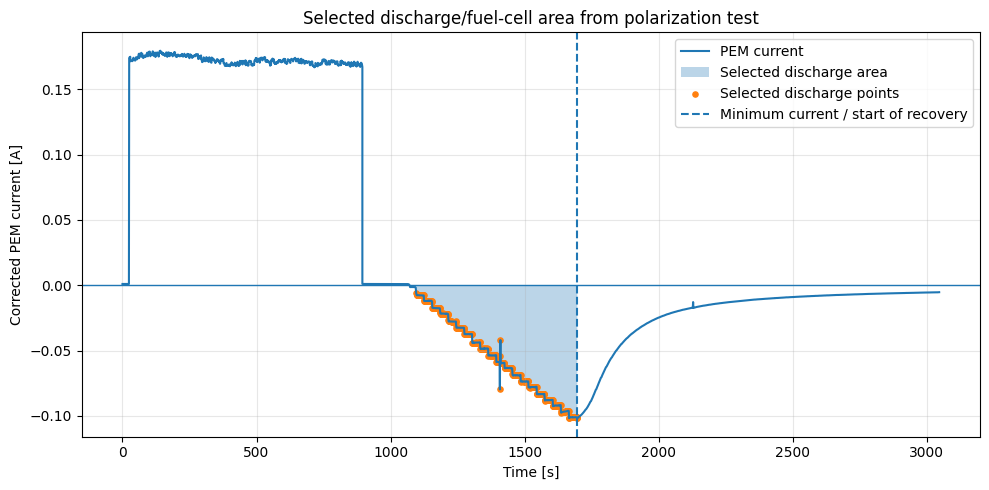

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    polarization["time_s"],
    polarization["pem_current_A"],
    label="PEM current",
    linewidth=1.5,
)

ax.fill_between(
    active_discharge["time_s"],
    active_discharge["pem_current_A"],
    0,
    alpha=0.3,
    label="Selected discharge area",
)

ax.scatter(
    active_discharge["time_s"],
    active_discharge["pem_current_A"],
    s=14,
    label="Selected discharge points",
)

ax.axvline(
    t_min_current,
    linestyle="--",
    label="Minimum current / start of recovery",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Corrected PEM current [A]")
ax.set_title("Selected discharge/fuel-cell area from polarization test")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

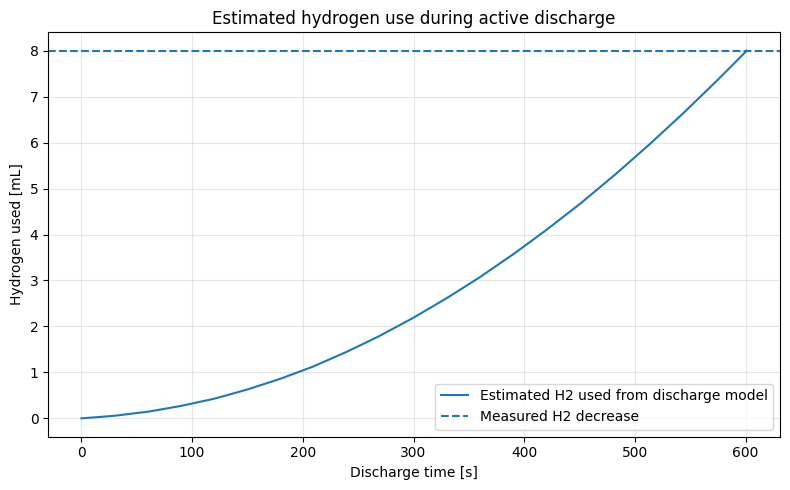

In [13]:
# Cumulative hydrogen use during the selected discharge region.
discharge_profile = active_discharge.copy()

t = discharge_profile["discharge_time_s"].to_numpy()
I = discharge_profile["pem_discharge_current_A"].to_numpy()

dt = np.diff(t)
cumulative_charge_C = np.concatenate([
    [0],
    np.cumsum(0.5 * (I[:-1] + I[1:]) * dt)
])

discharge_profile["cumulative_output_charge_C"] = cumulative_charge_C
discharge_profile["estimated_H2_used_mL"] = (
    discharge_profile["cumulative_output_charge_C"] * HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C
)

plt.figure(figsize=(8, 5))
plt.plot(
    discharge_profile["discharge_time_s"],
    discharge_profile["estimated_H2_used_mL"],
    label="Estimated H2 used from discharge model",
)

plt.axhline(
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
    linestyle="--",
    label="Measured H2 decrease",
)

plt.xlabel("Discharge time [s]")
plt.ylabel("Hydrogen used [mL]")
plt.title("Estimated hydrogen use during active discharge")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Final constants for the EMS/SoH model

The final model is current-based, so the most important constants are the `mL/C` values.  
The average `mL/min` rates are useful for interpretation, but they only represent the average behaviour during the selected calibration intervals.

In [14]:
ems_parameters = pd.DataFrame({
    "parameter": [
        "H2_MAX_ML",
        "H2_MIN_USABLE_ML",
        "H2_USABLE_ML",
        "HYDROGEN_PRODUCTION_ML_PER_INPUT_C",
        "HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C",
        "HYDROGEN_CHARGE_RATE_ML_PER_MIN",
        "HYDROGEN_DISCHARGE_RATE_ML_PER_MIN",
        "CHARGE_CURRENT_THRESHOLD_A",
        "DISCHARGE_CURRENT_THRESHOLD_A",
    ],
    "value": [
        MEASURED_FULL_HYDROGEN_CAPACITY_ML,
        MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML,
        MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
        HYDROGEN_PRODUCTION_ML_PER_INPUT_C,
        HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C,
        HYDROGEN_CHARGE_RATE_ML_PER_MIN,
        HYDROGEN_DISCHARGE_RATE_ML_PER_MIN,
        CHARGE_CURRENT_THRESHOLD_A,
        DISCHARGE_CURRENT_THRESHOLD_A,
    ],
    "unit": [
        "mL", "mL", "mL", "mL/C", "mL/C", "mL/min", "mL/min", "A", "A",
    ],
    "meaning": [
        "Measured full hydrogen capacity",
        "Measured remaining hydrogen after active discharge",
        "Usable hydrogen window",
        "Final charge constant from polarization charge test",
        "Final discharge constant from polarization discharge test",
        "Average charge rate during full selected charge interval",
        "Average discharge rate during selected active discharge interval",
        "Minimum current used to identify active electrolysis",
        "Maximum negative current threshold used to identify active discharge",
    ],
})

display(ems_parameters)

,parameter,value,unit,meaning
0,H2_MAX_ML,15.600000,mL,Measured full hydrogen capacity
1,H2_MIN_USABLE_ML,7.600000,mL,Measured remaining hydrogen after active disch...
2,H2_USABLE_ML,8.000000,mL,Usable hydrogen window
3,HYDROGEN_PRODUCTION_ML_PER_INPUT_C,0.104212,mL/C,Final charge constant from polarization charge...
4,HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C,0.239476,mL/C,Final discharge constant from polarization dis...
5,HYDROGEN_CHARGE_RATE_ML_PER_MIN,1.077100,mL/min,Average charge rate during full selected charg...
6,HYDROGEN_DISCHARGE_RATE_ML_PER_MIN,0.798669,mL/min,Average discharge rate during selected active ...
7,CHARGE_CURRENT_THRESHOLD_A,0.050000,A,Minimum current used to identify active electr...
8,DISCHARGE_CURRENT_THRESHOLD_A,-0.005000,A,Maximum negative current threshold used to ide...


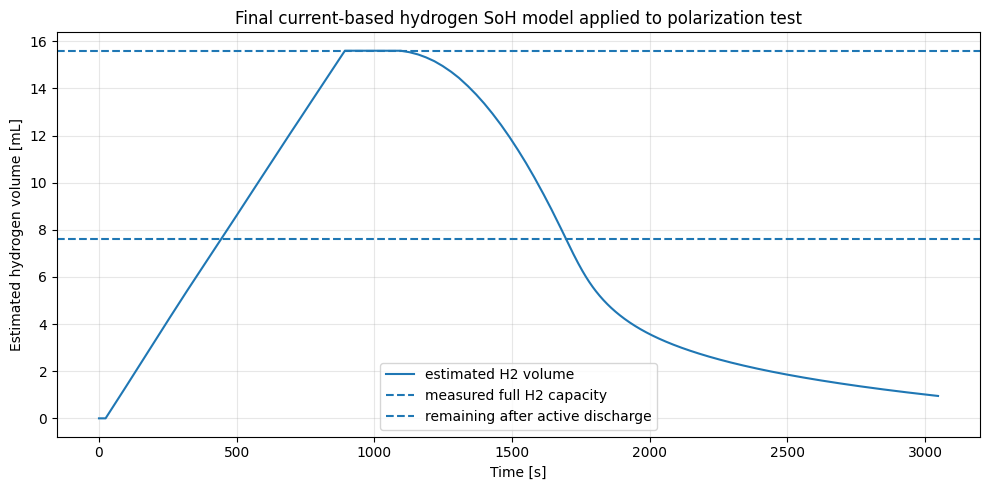

,timestamp,scenario,mode,time_s,pem_current_A,estimated_h2_mL,usable_soh_percent
2887,2026-05-05 10:31:10,6,Scenario 6: PEM -> Load,3043.0,-0.005407,0.955391,0.0
2888,2026-05-05 10:31:11,6,Scenario 6: PEM -> Load,3044.0,-0.005407,0.954097,0.0
2889,2026-05-05 10:31:12,6,Scenario 6: PEM -> Load,3045.0,-0.005386,0.952807,0.0
2890,2026-05-05 10:31:13,6,Scenario 6: PEM -> Load,3046.0,-0.005407,0.951512,0.0
2891,2026-05-05 10:31:14,6,Scenario 6: PEM -> Load,3047.0,-0.005344,0.950232,0.0


In [15]:
def estimate_h2_profile_from_current(
    df: pd.DataFrame,
    initial_h2_mL: float = 0.0,
    h2_min_mL: float = 0.0,
    h2_max_mL: float = MEASURED_FULL_HYDROGEN_CAPACITY_ML,
) -> pd.DataFrame:
    """
    Apply the final current-based H2 SoH model to a measured PEM current profile.
    Positive current charges the H2 storage; negative current discharges it.
    """
    out = df.copy()
    out["dt_s"] = out["time_s"].diff().fillna(0)

    h2_values = []
    h2_mL = initial_h2_mL

    for _, row in out.iterrows():
        I = row["pem_current_A"]
        dt_s = row["dt_s"]

        if I > CHARGE_CURRENT_THRESHOLD_A:
            h2_mL += HYDROGEN_PRODUCTION_ML_PER_INPUT_C * I * dt_s

        elif I < DISCHARGE_CURRENT_THRESHOLD_A:
            h2_mL -= HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C * abs(I) * dt_s

        h2_mL = min(max(h2_mL, h2_min_mL), h2_max_mL)
        h2_values.append(h2_mL)

    out["estimated_h2_mL"] = h2_values
    out["usable_soh"] = (
        (out["estimated_h2_mL"] - MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML)
        / MEASURED_USABLE_HYDROGEN_DISCHARGE_ML
    ).clip(0, 1)

    out["usable_soh_percent"] = 100 * out["usable_soh"]

    return out


# Example: apply the final SoH model to the polarization test.
# The test starts before the full charge, so initial H2 is set to 0 mL.
soh_profile = estimate_h2_profile_from_current(
    polarization,
    initial_h2_mL=0.0,
    h2_min_mL=0.0,
    h2_max_mL=MEASURED_FULL_HYDROGEN_CAPACITY_ML,
)

plt.figure(figsize=(10, 5))
plt.plot(
    soh_profile["time_s"],
    soh_profile["estimated_h2_mL"],
    label="estimated H2 volume",
)

plt.axhline(MEASURED_FULL_HYDROGEN_CAPACITY_ML, linestyle="--", label="measured full H2 capacity")
plt.axhline(MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML, linestyle="--", label="remaining after active discharge")

plt.xlabel("Time [s]")
plt.ylabel("Estimated hydrogen volume [mL]")
plt.title("Final current-based hydrogen SoH model applied to polarization test")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(
    soh_profile[
        ["timestamp", "scenario", "mode", "time_s", "pem_current_A", "estimated_h2_mL", "usable_soh_percent"]
    ].tail()
)

## Interpretation

The final EMS/SoH model should use the current-based constants:

\[
k_{H_2,\mathrm{charge}} = 0.10421~\mathrm{mL/C}
\]

\[
k_{H_2,\mathrm{discharge}} = 0.23948~\mathrm{mL/C}
\]

The charge constant is based on the full Scenario 3 electrolysis interval in the polarization test.  
The discharge constant is based on the active Scenario 6 fuel-cell interval, where the hydrogen volume decreased from 15.6 mL to 7.6 mL.

The short tests are used only as validation, because their manual volume readings are small and therefore relatively noisy.